# TEG Dehydration & Regeneration with Emission Accounting (CPA EOS)

This notebook builds a **complete triethylene-glycol (TEG) dehydration plant** in NeqSim and
computes the **atmospheric emissions** from the regeneration system, including **NMVOC**
(non-methane volatile organic compounds) and methane (CH₄, a greenhouse gas).

It reproduces the two parts of *"The TEG system"* (after Campbell):

1. **Dehydration (absorption)** — wet feed gas is contacted with lean TEG in a glycol
   contactor; dry gas leaves the top, rich (water-loaded) TEG leaves the bottom.
2. **Regeneration (desorption) with 2 exchangers** — rich TEG is flashed in a flash/degassing
   drum, pre-heated through lean/rich exchangers, regenerated in a still column with a reboiler
   and a stripping-gas (water-stripper) section, then pumped and cooled back to the absorber
   through a closed TEG recycle loop.

The plant is modelled with the **CPA equation of state** (`SystemSrkCPAStatoil`, mixing rule 10), which
is the correct choice for the polar water–TEG–hydrocarbon system.

### Emission points (vents)

| Vent | Source | Notes |
|------|--------|-------|
| **Flash gas** | Degassing (flash) drum gas outlet | Usually recovered to fuel gas |
| **Still vent** | Regenerator overhead (off-gas after the reflux/condenser) | The *atmospheric* vent unless routed to flare/incinerator |

### Why this matters — plants with recirculated stripping gas

In *most* TEG plants all gas and liquid from the regeneration section are recycled back to the
main process, so there is **no** atmospheric vent. But on plants that use **recirculated
stripping gas**, the wet still off-gas cannot all be recovered and is released to an
**atmospheric vent** — this is a real, reportable emission of NMVOC, CH₄ and BTEX (benzene).

On the Norwegian shelf this configuration applies to a handful of assets — e.g. **Kristin**
(currently over its emission limit), **Snorre B** and **Norne**. A TEG model that *already*
includes the atmospheric-vent emissions lets these assets:

- build an emissions report for the relevant plants without re-work later, and
- demonstrate to **Miljødirektoratet** that the vent emissions are being tracked.

This notebook is therefore written as a **reusable template**: change the per-plant feed
composition, flow, TEG rate, stripping-gas rate and flash-drum pressure (Section 4) and the
emission accounting follows automatically. It is intended as a starting point for the TEG
models being implemented in **Almond**.

### Key study question (from the slide)

> *Lowering the flash-gas drum pressure reduces the atmospheric emissions.*

We reproduce this by sweeping the flash-drum pressure and tracking the still-vent NMVOC load.

The model is written as a single `build_teg_plant(...)` function so it can later be wired to
**live/online plant data** (feed composition, flow, TEG rate, temperatures) for an online model.

## 1. Imports

We use the direct Java-access pattern (`from neqsim import jneqsim`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from neqsim import jneqsim

# Thermo
SystemSrkCPA = jneqsim.thermo.system.SystemSrkCPAStatoil

# Process framework
ProcessSystem = jneqsim.process.processmodel.ProcessSystem
Stream = jneqsim.process.equipment.stream.Stream

# Equipment
StreamSaturatorUtil = jneqsim.process.equipment.util.StreamSaturatorUtil
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
SimpleTEGAbsorber = jneqsim.process.equipment.absorber.SimpleTEGAbsorber
WaterStripperColumn = jneqsim.process.equipment.absorber.WaterStripperColumn
DistillationColumn = jneqsim.process.equipment.distillation.DistillationColumn
Separator = jneqsim.process.equipment.separator.Separator
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Filter = jneqsim.process.equipment.filter.Filter
Pump = jneqsim.process.equipment.pump.Pump
Mixer = jneqsim.process.equipment.mixer.Mixer
Calculator = jneqsim.process.equipment.util.Calculator
Recycle = jneqsim.process.equipment.util.Recycle
WaterDewPointAnalyser = jneqsim.process.measurementdevice.WaterDewPointAnalyser

print('NeqSim classes loaded.')

NeqSim classes loaded.


## 2. Component list and NMVOC definition

The feed-gas component order is fixed and reused for every fluid built by cloning. The TEG and
make-up streams set their composition with `setMolarComposition(...)` against **this exact order**.

**NMVOC** = all volatile organic (hydrocarbon) components **except methane**. Methane is tracked
separately as a greenhouse-gas (GHG) emission. N₂, CO₂, water and TEG are **not** NMVOC.

In [2]:
# Fixed component order (index used by setMolarComposition arrays below)
COMPONENTS = [
    'nitrogen', 'CO2', 'methane', 'ethane', 'propane', 'i-butane', 'n-butane',
    'i-pentane', 'n-pentane', 'n-hexane', 'benzene', 'water', 'TEG'
]

# NMVOC = non-methane volatile organic compounds (hydrocarbons, incl. BTEX/benzene)
NMVOC = {'ethane', 'propane', 'i-butane', 'n-butane', 'i-pentane',
         'n-pentane', 'n-hexane', 'benzene'}
GHG_CH4 = {'methane'}

print('Components:', COMPONENTS)
print('NMVOC set :', sorted(NMVOC))

Components: ['nitrogen', 'CO2', 'methane', 'ethane', 'propane', 'i-butane', 'n-butane', 'i-pentane', 'n-pentane', 'n-hexane', 'benzene', 'water', 'TEG']
NMVOC set : ['benzene', 'ethane', 'i-butane', 'i-pentane', 'n-butane', 'n-hexane', 'n-pentane', 'propane']


## 3. Build the full TEG plant

The whole flowsheet (absorber + flash/degassing drum + lean/rich exchangers + still column with
reboiler/condenser + water-stripper + closed TEG recycle with make-up) is wrapped in one function.
The `flash_drum_pressure_bara` argument is the controllable variable for the sensitivity study.

In [3]:
def build_teg_plant(flash_drum_pressure_bara=4.8,
                    teg_flow_kg_hr=5500.0,
                    feed_flow_MSm3_day=4.65,
                    reboiler_temp_C=197.5,
                    stripping_gas_Sm3_hr=180.0):
    """Build and return (process, streams) for the TEG dehydration + regeneration plant."""
    p = ProcessSystem()

    # ---- Feed gas (CPA, mixing rule 10) ----
    feedGas = SystemSrkCPAStatoil()
    feedGas.addComponent('nitrogen', 0.245)
    feedGas.addComponent('CO2', 3.4)
    feedGas.addComponent('methane', 85.7)
    feedGas.addComponent('ethane', 5.981)
    feedGas.addComponent('propane', 2.743)
    feedGas.addComponent('i-butane', 0.37)
    feedGas.addComponent('n-butane', 0.77)
    feedGas.addComponent('i-pentane', 0.142)
    feedGas.addComponent('n-pentane', 0.166)
    feedGas.addComponent('n-hexane', 0.06)
    feedGas.addComponent('benzene', 0.01)
    feedGas.addComponent('water', 0.0)
    feedGas.addComponent('TEG', 0.0)
    feedGas.setMixingRule(10)
    feedGas.setMultiPhaseCheck(False)
    feedGas.init(0)

    # ---- Dry feed gas stream ----
    dryFeedGas = Stream('dry feed gas', feedGas)
    dryFeedGas.setFlowRate(feed_flow_MSm3_day, 'MSm3/day')
    dryFeedGas.setTemperature(25.0, 'C')
    dryFeedGas.setPressure(70.0, 'bara')
    p.add(dryFeedGas)

    # ---- Saturate feed gas with water ----
    saturator = StreamSaturatorUtil('water saturator', dryFeedGas)
    p.add(saturator)
    wetFeedGas = Stream('water saturated feed gas', saturator.getOutletStream())
    p.add(wetFeedGas)

    feedTPsetter = Heater('TP of gas to absorber', wetFeedGas)
    feedTPsetter.setOutPressure(85.0, 'bara')
    feedTPsetter.setOutTemperature(35.0, 'C')
    p.add(feedTPsetter)
    feedToAbsorber = Stream('feed to TEG absorber', feedTPsetter.getOutletStream())
    p.add(feedToAbsorber)

    # ---- Lean TEG feed (composition set against COMPONENTS order: water 0.03, TEG 0.97) ----
    feedTEG = feedGas.clone()
    feedTEG.setMolarComposition(
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.03, 0.97])
    TEGFeed = Stream('TEG feed', feedTEG)
    TEGFeed.setFlowRate(teg_flow_kg_hr, 'kg/hr')
    TEGFeed.setTemperature(48.5, 'C')
    TEGFeed.setPressure(85.0, 'bara')
    p.add(TEGFeed)

    # ---- TEG absorber (dehydration) ----
    absorber = SimpleTEGAbsorber('TEG absorber')
    absorber.addGasInStream(feedToAbsorber)
    absorber.addSolventInStream(TEGFeed)
    absorber.setNumberOfStages(4)
    absorber.setStageEfficiency(0.7)
    absorber.setInternalDiameter(2.240)
    p.add(absorber)

    dehydratedGas = Stream('dry gas from absorber', absorber.getGasOutStream())
    p.add(dehydratedGas)
    richTEG = Stream('rich TEG from absorber', absorber.getLiquidOutStream())
    p.add(richTEG)

    waterDewAnalyser = WaterDewPointAnalyser('water dew point analyser', dehydratedGas)
    waterDewAnalyser.setReferencePressure(70.0)
    p.add(waterDewAnalyser)

    # ---- Rich TEG flash / degassing drum (controllable pressure) ----
    flashValve = ThrottlingValve('Rich TEG HP flash valve', richTEG)
    flashValve.setOutletPressure(flash_drum_pressure_bara)
    p.add(flashValve)

    richPreheat = Heater('rich TEG preheater', flashValve.getOutletStream())
    p.add(richPreheat)

    heatEx2 = HeatExchanger('rich TEG heat exchanger 1', richPreheat.getOutletStream())
    heatEx2.setGuessOutTemperature(273.15 + 62.0)
    heatEx2.setUAvalue(2224.0)
    p.add(heatEx2)

    flashSep = Separator('degassing separator', heatEx2.getOutStream(0))
    flashSep.setInternalDiameter(1.2)
    p.add(flashSep)
    flashGas = Stream('gas from degassing separator', flashSep.getGasOutStream())
    p.add(flashGas)
    flashLiquid = Stream('liquid from degassing separator', flashSep.getLiquidOutStream())
    p.add(flashLiquid)

    fineFilter = Filter('TEG fine filter', flashLiquid)
    fineFilter.setDeltaP(0.0, 'bara')
    p.add(fineFilter)

    heatEx = HeatExchanger('lean/rich TEG heat-exchanger', fineFilter.getOutletStream())
    heatEx.setGuessOutTemperature(273.15 + 130.0)
    heatEx.setUAvalue(8316.0)
    p.add(heatEx)

    flashValve2 = ThrottlingValve('Rich TEG LP flash valve', heatEx.getOutStream(0))
    flashValve2.setOutletPressure(1.2)
    p.add(flashValve2)

    # ---- Stripping gas to still / stripper ----
    stripGas = feedGas.clone()
    strippingGas = Stream('stripGas', stripGas)
    strippingGas.setFlowRate(stripping_gas_Sm3_hr, 'Sm3/hr')
    strippingGas.setTemperature(78.3, 'C')
    strippingGas.setPressure(1.2, 'bara')
    p.add(strippingGas)
    gasToReboiler = strippingGas.clone('gas to reboiler')
    p.add(gasToReboiler)

    # ---- TEG regeneration still column (reboiler + condenser) ----
    column = DistillationColumn('TEG regeneration column', 1, True, True)
    column.setTemperatureTolerance(5.0e-2)
    column.setMassBalanceTolerance(2.0e-1)
    column.setEnthalpyBalanceTolerance(2.0e-1)
    column.addFeedStream(flashValve2.getOutletStream(), 1)
    column.getReboiler().setOutTemperature(273.15 + reboiler_temp_C)
    column.getCondenser().setOutTemperature(273.15 + 85.0)
    column.getTray(1).addStream(gasToReboiler)
    column.setTopPressure(1.2)
    column.setBottomPressure(1.2)
    column.setInternalDiameter(0.56)
    p.add(column)

    coolerRegenGas = Heater('regen gas cooler', column.getGasOutStream())
    coolerRegenGas.setOutTemperature(273.15 + 47.0)
    p.add(coolerRegenGas)

    sepRegenGas = Separator('regen gas separator', coolerRegenGas.getOutletStream())
    p.add(sepRegenGas)
    stillVent = Stream('still vent to atmosphere', sepRegenGas.getGasOutStream())
    p.add(stillVent)
    waterToTreatment = Stream('water to treatment', sepRegenGas.getLiquidOutStream())
    p.add(waterToTreatment)

    # ---- Water stripper (lean TEG enrichment) ----
    stripper = WaterStripperColumn('TEG stripper')
    stripper.addSolventInStream(column.getLiquidOutStream())
    stripper.addGasInStream(strippingGas)
    stripper.setNumberOfStages(2)
    stripper.setStageEfficiency(1.0)
    p.add(stripper)

    recycleStripGas = Recycle('stripping gas recirc')
    recycleStripGas.addStream(stripper.getGasOutStream())
    recycleStripGas.setOutletStream(gasToReboiler)
    p.add(recycleStripGas)

    heatEx.setFeedStream(1, stripper.getLiquidOutStream())

    bufferTank = Heater('TEG buffer tank', heatEx.getOutStream(1))
    bufferTank.setOutTemperature(273.15 + 90.5)
    p.add(bufferTank)

    leanPumpLP = Pump('lean TEG LP pump', bufferTank.getOutletStream())
    leanPumpLP.setOutletPressure(3.0)
    leanPumpLP.setIsentropicEfficiency(0.75)
    p.add(leanPumpLP)

    heatEx2.setFeedStream(1, leanPumpLP.getOutletStream())

    coolerLeanTEG = Heater('lean TEG cooler', heatEx2.getOutStream(1))
    coolerLeanTEG.setOutTemperature(273.15 + 48.5)
    p.add(coolerLeanTEG)

    leanPumpHP = Pump('lean TEG HP pump', coolerLeanTEG.getOutletStream())
    leanPumpHP.setOutletPressure(85.0)
    leanPumpHP.setIsentropicEfficiency(0.75)
    p.add(leanPumpHP)

    leanTEGtoAbs = Stream('lean TEG to absorber', leanPumpHP.getOutletStream())
    p.add(leanTEGtoAbs)

    # ---- TEG make-up (replaces TEG lost to the vents) ----
    pureTEG = feedGas.clone()
    pureTEG.setMolarComposition(
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0])
    makeupTEG = Stream('makeup TEG', pureTEG)
    makeupTEG.setFlowRate(1e-6, 'kg/hr')
    makeupTEG.setTemperature(48.5, 'C')
    makeupTEG.setPressure(85.0, 'bara')
    p.add(makeupTEG)

    makeupCalc = Calculator('TEG makeup calculator')
    makeupCalc.addInputVariable(dehydratedGas)
    makeupCalc.addInputVariable(flashGas)
    makeupCalc.addInputVariable(stillVent)
    makeupCalc.addInputVariable(waterToTreatment)
    makeupCalc.setOutputVariable(makeupTEG)
    p.add(makeupCalc)

    makeupMixer = Mixer('makeup mixer')
    makeupMixer.addStream(leanTEGtoAbs)
    makeupMixer.addStream(makeupTEG)
    p.add(makeupMixer)

    recycleLeanTEG = Recycle('lean TEG recycle')
    recycleLeanTEG.addStream(makeupMixer.getOutletStream())
    recycleLeanTEG.setOutletStream(TEGFeed)
    recycleLeanTEG.setPriority(200)
    recycleLeanTEG.setDownstreamProperty('flow rate')
    p.add(recycleLeanTEG)

    # Couple the rich-glycol preheater to the column condenser duty (heat recovery)
    richPreheat.setEnergyStream(column.getCondenser().getEnergyStream())

    streams = {
        'dehydratedGas': dehydratedGas,
        'richTEG': richTEG,
        'flashGas': flashGas,
        'stillVent': stillVent,
        'waterToTreatment': waterToTreatment,
        'leanTEGtoAbs': leanTEGtoAbs,
        'waterDewAnalyser': waterDewAnalyser,
        'column': column,
    }
    return p, streams

print('build_teg_plant() defined.')

build_teg_plant() defined.


## 4. Run the base case

We build the plant at the base flash-drum pressure (4.8 bara) and solve the closed recycle
loop. The run is executed on a worker thread with a timeout, which is the robust pattern for
recycle-heavy TEG flowsheets.

In [4]:
def run_plant(process, timeout_ms=300000):
    """Run the process on a worker thread (robust for recycle convergence)."""
    thr = process.runAsThread()
    thr.join(timeout_ms)
    return process

process, S = build_teg_plant(flash_drum_pressure_bara=4.8)
run_plant(process)
print('Base-case run complete.')

Base-case run complete.


## 5. Dehydration performance

Check the dry-gas water dew point and the lean-TEG purity (the key dehydration KPIs).

In [5]:
def comp_mass_flows_kg_hr(stream):
    """Return {component_name: mass_flow_kg_hr} from a stream's overall composition."""
    fluid = stream.getFluid()
    total = stream.getFlowRate('kg/hr')
    n = fluid.getNumberOfComponents()
    zM = []
    names = []
    for i in range(n):
        c = fluid.getComponent(i)
        names.append(str(c.getComponentName()))
        zM.append(c.getz() * c.getMolarMass())
    s = sum(zM)
    if s <= 0:
        return {names[i]: 0.0 for i in range(n)}
    return {names[i]: (zM[i] / s) * total for i in range(n)}


def teg_mass_fraction(stream):
    flows = comp_mass_flows_kg_hr(stream)
    tot = sum(flows.values())
    return 100.0 * flows.get('TEG', 0.0) / tot if tot > 0 else 0.0


water_dew_C = S['waterDewAnalyser'].getMeasuredValue('C')
lean_teg_wt = teg_mass_fraction(S['leanTEGtoAbs'])
dry_gas_flow = S['dehydratedGas'].getFlowRate('MSm3/day')

# The reboiler exports its heat through the condenser energy stream that is
# coupled to the rich-TEG preheater, so the column's internal reboiler `duty`
# field can read NaN in the converged state. Report it only when finite.
reboiler_duty_kW = float(S['column'].getReboiler().getDuty()) / 1e3

print(f'Dry-gas water dew point  : {water_dew_C:8.2f} degC (at 70 bara)')
print(f'Lean TEG purity          : {lean_teg_wt:8.3f} wt%')
print(f'Dry gas flow             : {dry_gas_flow:8.3f} MSm3/day')
if np.isfinite(reboiler_duty_kW):
    print(f'Reboiler duty            : {reboiler_duty_kW:8.1f} kW')
else:
    print('Reboiler duty            :      n/a (heat coupled to preheater energy stream)')

Dry-gas water dew point  :   -29.25 degC (at 70 bara)
Lean TEG purity          :   99.992 wt%
Dry gas flow             :    4.648 MSm3/day
Reboiler duty            :      n/a (heat coupled to preheater energy stream)


## 6. Emission accounting (NMVOC, CH₄, CO₂)

We sum the component mass flows in each vent and classify them into **NMVOC**, **methane (CH₄)**,
**CO₂**, **water** and **TEG loss**. The *still vent* is the atmospheric emission; the *flash gas*
is normally recovered to fuel (shown for comparison).

In [6]:
def classify_emissions(stream):
    """Return a dict of grouped mass flows (kg/hr) for a vent stream."""
    flows = comp_mass_flows_kg_hr(stream)
    out = {
        'NMVOC': sum(v for k, v in flows.items() if k in NMVOC),
        'methane': sum(v for k, v in flows.items() if k in GHG_CH4),
        'CO2': flows.get('CO2', 0.0),
        'nitrogen': flows.get('nitrogen', 0.0),
        'water': flows.get('water', 0.0),
        'TEG': flows.get('TEG', 0.0),
    }
    out['total'] = sum(flows.values())
    out['benzene'] = flows.get('benzene', 0.0)  # BTEX marker (subset of NMVOC)
    return out


still = classify_emissions(S['stillVent'])
flash = classify_emissions(S['flashGas'])

print('=== Atmospheric STILL VENT (regenerator overhead) ===')
for k in ['total', 'NMVOC', 'methane', 'CO2', 'water', 'TEG', 'benzene']:
    print(f'  {k:10s}: {still[k]:10.4f} kg/hr')
print()
print('=== FLASH GAS (degassing drum, normally to fuel) ===')
for k in ['total', 'NMVOC', 'methane', 'CO2', 'water', 'TEG', 'benzene']:
    print(f'  {k:10s}: {flash[k]:10.4f} kg/hr')
print()
print(f'NMVOC to atmosphere (still vent): {still["NMVOC"]:.3f} kg/hr '
      f'= {still["NMVOC"]*24/1000:.3f} t/day')

=== Atmospheric STILL VENT (regenerator overhead) ===
  total     :   177.2046 kg/hr
  NMVOC     :    43.7648 kg/hr
  methane   :   105.5718 kg/hr
  CO2       :    15.5919 kg/hr
  water     :    11.7512 kg/hr
  TEG       :     0.0000 kg/hr
  benzene   :     4.8721 kg/hr

=== FLASH GAS (degassing drum, normally to fuel) ===
  total     :    84.1018 kg/hr
  NMVOC     :    28.7241 kg/hr
  methane   :    21.0440 kg/hr
  CO2       :    23.1082 kg/hr
  water     :    10.9939 kg/hr
  TEG       :     0.1630 kg/hr
  benzene   :     0.7399 kg/hr

NMVOC to atmosphere (still vent): 43.765 kg/hr = 1.050 t/day


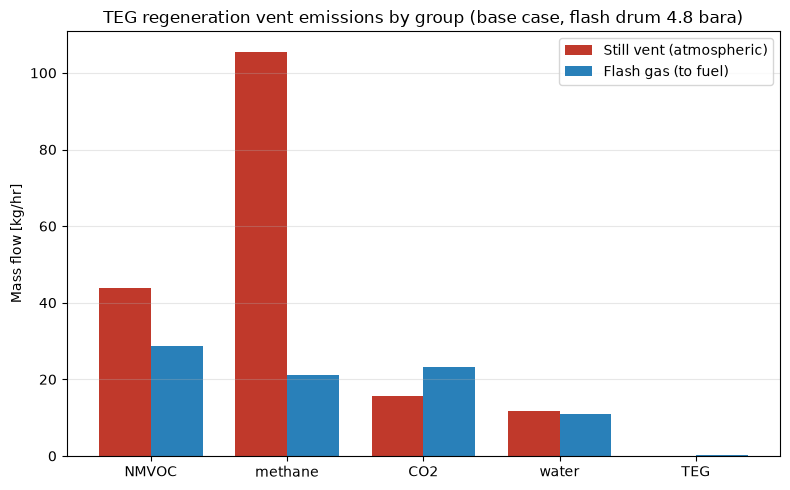

In [7]:
# Figure 1: emission breakdown of the still vent vs the flash gas
groups = ['NMVOC', 'methane', 'CO2', 'water', 'TEG']
still_vals = [still[g] for g in groups]
flash_vals = [flash[g] for g in groups]

x = np.arange(len(groups))
w = 0.38
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, still_vals, w, label='Still vent (atmospheric)', color='#c0392b')
ax.bar(x + w/2, flash_vals, w, label='Flash gas (to fuel)', color='#2980b9')
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylabel('Mass flow [kg/hr]')
ax.set_title('TEG regeneration vent emissions by group (base case, flash drum 4.8 bara)')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6b. Annual emission roll-up (tonnes/year — reporting basis)

Environmental reporting to **Miljødirektoratet** is on a **tonnes-per-year** basis, so the kg/hr
vent loads are scaled by the annual operating hours. The **atmospheric still vent** is the
reportable emission for plants with recirculated stripping gas; the **flash gas** is normally
recovered to fuel and shown here only for comparison.

Adjust `operating_hours_per_year` to the plant's actual on-stream time.


In [11]:
# Annual emission roll-up (tonnes/year) for the reportable atmospheric still vent
operating_hours_per_year = 8000.0  # adjust to the plant's actual on-stream hours

def annual_tonnes(vent, hours=operating_hours_per_year):
    """Convert grouped kg/hr vent loads to tonnes/year."""
    return {k: v * hours / 1000.0 for k, v in vent.items()}

still_ty = annual_tonnes(still)
flash_ty = annual_tonnes(flash)

print(f'Annual basis: {operating_hours_per_year:.0f} operating hours/year\n')
print('Component   | Still vent (ATM) | Flash gas (fuel)')
print('            |    [t/year]      |    [t/year]')
print('-' * 52)
for k in ['NMVOC', 'methane', 'CO2', 'benzene', 'water', 'TEG', 'total']:
    print(f'  {k:9s} | {still_ty[k]:13.2f}    | {flash_ty[k]:13.2f}')

print(f'\nReportable atmospheric emissions (still vent):')
print(f'  NMVOC   : {still_ty["NMVOC"]:8.1f} t/year')
print(f'  CH4     : {still_ty["methane"]:8.1f} t/year')
print(f'  benzene : {still_ty["benzene"]:8.2f} t/year (BTEX marker)')
print(f'  CO2     : {still_ty["CO2"]:8.1f} t/year')


Annual basis: 8000 operating hours/year

Component   | Still vent (ATM) | Flash gas (fuel)
            |    [t/year]      |    [t/year]
----------------------------------------------------
  NMVOC     |        350.12    |        229.79
  methane   |        844.57    |        168.35
  CO2       |        124.74    |        184.87
  benzene   |         38.98    |          5.92
  water     |         94.01    |         87.95
  TEG       |          0.00    |          1.30
  total     |       1417.64    |        672.81

Reportable atmospheric emissions (still vent):
  NMVOC   :    350.1 t/year
  CH4     :    844.6 t/year
  benzene :    38.98 t/year (BTEX marker)
  CO2     :    124.7 t/year


## 7. Sensitivity: flash-drum pressure vs atmospheric emissions

The slide states that **lowering the flash-gas drum pressure reduces atmospheric emissions**.
Mechanism: a lower flash-drum pressure releases more dissolved light hydrocarbons (NMVOC) into
the *recovered* flash gas, so fewer volatiles remain in the rich TEG entering the still — hence a
smaller NMVOC load on the atmospheric still vent.

We rebuild and solve the plant at several flash-drum pressures and track the still-vent NMVOC.

In [8]:
flash_pressures = [2.0, 3.0, 4.8, 7.0, 9.0]
still_nmvoc = []
flash_nmvoc = []
still_total = []

for pf in flash_pressures:
    proc, Ss = build_teg_plant(flash_drum_pressure_bara=pf)
    run_plant(proc)
    st = classify_emissions(Ss['stillVent'])
    fl = classify_emissions(Ss['flashGas'])
    still_nmvoc.append(st['NMVOC'])
    flash_nmvoc.append(fl['NMVOC'])
    still_total.append(st['total'])
    print(f'flash drum {pf:4.1f} bara -> still-vent NMVOC {st["NMVOC"]:7.3f} kg/hr | '
          f'flash-gas NMVOC {fl["NMVOC"]:7.3f} kg/hr')

flash drum  2.0 bara -> still-vent NMVOC  36.468 kg/hr | flash-gas NMVOC  35.581 kg/hr
flash drum  3.0 bara -> still-vent NMVOC  39.413 kg/hr | flash-gas NMVOC  32.609 kg/hr
flash drum  4.8 bara -> still-vent NMVOC  43.277 kg/hr | flash-gas NMVOC  28.724 kg/hr
flash drum  7.0 bara -> still-vent NMVOC  71.958 kg/hr | flash-gas NMVOC   0.000 kg/hr
flash drum  9.0 bara -> still-vent NMVOC  71.588 kg/hr | flash-gas NMVOC   0.000 kg/hr


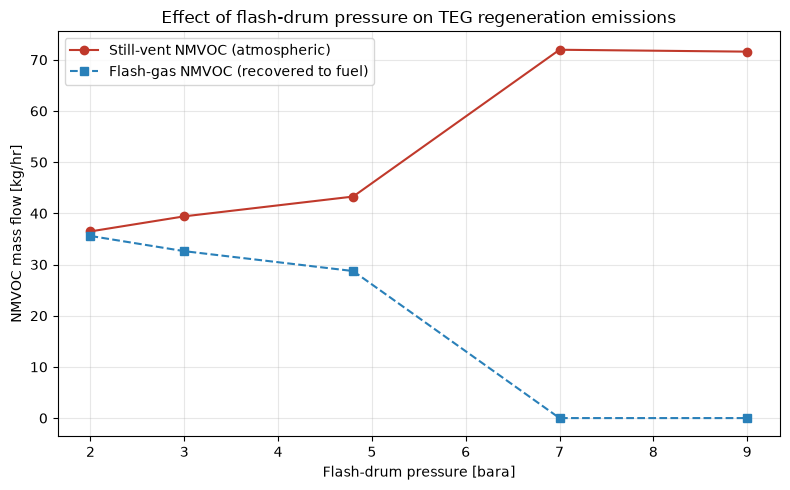

In [9]:
# Figure 2: flash-drum pressure sensitivity
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(flash_pressures, still_nmvoc, 'o-', color='#c0392b',
        label='Still-vent NMVOC (atmospheric)')
ax.plot(flash_pressures, flash_nmvoc, 's--', color='#2980b9',
        label='Flash-gas NMVOC (recovered to fuel)')
ax.set_xlabel('Flash-drum pressure [bara]')
ax.set_ylabel('NMVOC mass flow [kg/hr]')
ax.set_title('Effect of flash-drum pressure on TEG regeneration emissions')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Quantify the reduction from high to low flash-drum pressure (slide-style metric)
hi = still_nmvoc[flash_pressures.index(9.0)]
lo = still_nmvoc[flash_pressures.index(2.0)]
if hi > 0:
    reduction_pct = 100.0 * (hi - lo) / hi
    print(f'Still-vent NMVOC at 9.0 bara flash drum: {hi:.3f} kg/hr')
    print(f'Still-vent NMVOC at 2.0 bara flash drum: {lo:.3f} kg/hr')
    print(f'Reduction by lowering flash-drum pressure: {reduction_pct:.1f} %')

Still-vent NMVOC at 9.0 bara flash drum: 71.588 kg/hr
Still-vent NMVOC at 2.0 bara flash drum: 36.468 kg/hr
Reduction by lowering flash-drum pressure: 49.1 %


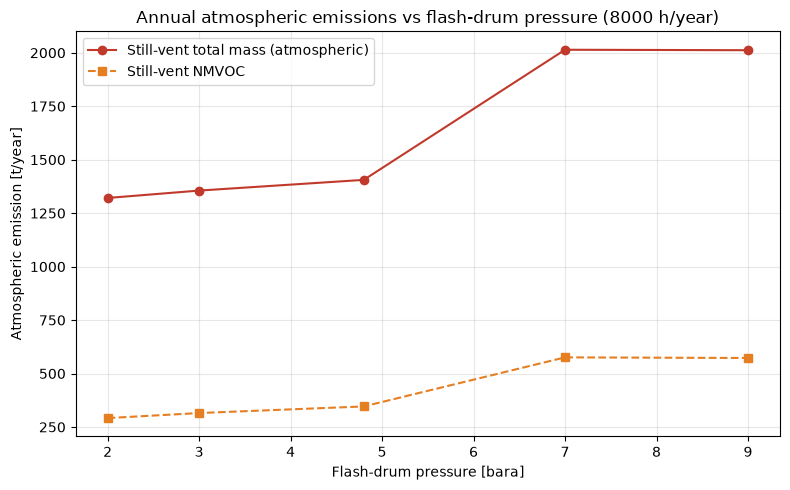

Still-vent total at 9.0 bara: 2012 t/year
Still-vent total at 2.0 bara: 1321 t/year
Annual reduction by lowering flash-drum pressure: 34 %


In [12]:
# Figure 3: annual still-vent emissions vs flash-drum pressure (t/year reporting basis,
# matching the Campbell slide). still_total / still_nmvoc come from the sweep above.
still_total_ty = [t * operating_hours_per_year / 1000.0 for t in still_total]
still_nmvoc_ty = [t * operating_hours_per_year / 1000.0 for t in still_nmvoc]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(flash_pressures, still_total_ty, 'o-', color='#c0392b',
        label='Still-vent total mass (atmospheric)')
ax.plot(flash_pressures, still_nmvoc_ty, 's--', color='#e67e22',
        label='Still-vent NMVOC')
ax.set_xlabel('Flash-drum pressure [bara]')
ax.set_ylabel('Atmospheric emission [t/year]')
ax.set_title(f'Annual atmospheric emissions vs flash-drum pressure '
             f'({operating_hours_per_year:.0f} h/year)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

hi_ty = still_total_ty[flash_pressures.index(9.0)]
lo_ty = still_total_ty[flash_pressures.index(2.0)]
print(f'Still-vent total at 9.0 bara: {hi_ty:.0f} t/year')
print(f'Still-vent total at 2.0 bara: {lo_ty:.0f} t/year')
print(f'Annual reduction by lowering flash-drum pressure: '
      f'{100.0 * (hi_ty - lo_ty) / hi_ty:.0f} %')


## 8. Conclusions & next steps

- The full **TEG dehydration + regeneration** plant is modelled with the **CPA EOS** and a closed
  TEG recycle loop (absorber → flash drum → lean/rich exchangers → still column with reboiler &
  stripping gas → pumps/cooler → back to absorber).
- **Emissions** are accounted at the two vents, split into **NMVOC**, **CH₄**, **CO₂**, water and
  TEG loss. Benzene is reported as a BTEX marker (a subset of NMVOC). An **annual roll-up in
  tonnes/year** (Section 6b) gives the **Miljødirektoratet reporting basis** for the atmospheric
  still vent.
- The **flash-drum pressure sweep** reproduces the slide finding: lowering the flash-drum
  pressure shifts NMVOC from the *atmospheric still vent* into the *recovered flash gas*, reducing
  atmospheric emissions (Figures 2 & 3).

### Using this notebook for the student report (Kristin, Snorre B, Norne, …)

These assets run **recirculated stripping gas**, which is exactly why they have a reportable
atmospheric vent. To build the report and the **Almond** TEG models so they *already* include the
vent emissions (no later re-work):

1. **One model per plant** — copy the base-case call in Section 4 and override the per-plant
   handles in `build_teg_plant(...)`: `feed_flow_MSm3_day`, `teg_flow_kg_hr`,
   `flash_drum_pressure_bara`, `reboiler_temp_C`, `stripping_gas_Sm3_hr`, and the feed
   composition in `COMPONENTS`. Start from design/operating data for Kristin, Snorre B and Norne.
2. **Always emit the still-vent tags** — when the Almond model is built, expose the still-vent
   NMVOC / CH₄ / benzene mass flows (and their t/year roll-up) as outputs from day one, so the
   plant can show Miljødirektoratet that the vent is tracked.
3. **Screen mitigation** — use the flash-drum pressure sweep to quantify how much a plant such as
   **Kristin** (currently over its limit) could cut its atmospheric emissions.

### Toward an online model

`build_teg_plant(...)` exposes the operational handles needed to bind to live data:
feed flow, feed/TEG temperatures and pressures, TEG circulation rate, reboiler temperature,
stripping-gas rate and the flash-drum pressure. Replace the hard-coded set-points with tag reads
(PI / IP.21) to drive an online emissions estimate — a license-free alternative to ProMax for
screening NMVOC from TEG plants with recirculated stripping gas.